# Bishop, *Pattern Recognition and Machine Learning* — §1.1–1.3

**Reading session notes — Week 1, Month 1.**

This notebook compiles a reading session over Bishop's §1.1 (Polynomial Curve Fitting),
§1.2 (Probability Theory), and §1.3 (Model Selection). It contains:

- **Grad-student summaries** of each section, with key derivations and worked exercises.
- **Figures** reproduced programmatically (shown statically, and regenerable via the code cells).
- A **Q&A log** of questions worked through during the session.

*How to use:* read top-to-bottom as notes; run the code cells to regenerate the figures.
Requires `numpy` and `matplotlib`.


# Bishop 1.1 — Example: Polynomial Curve Fitting

*Grad-student summary + worked exercises. Source: Bishop, PRML §1.1.*

## The setup

We are given a training set of $N$ observations of an input variable $x$ and a target $t$:
$$\mathbf{x} = (x_1, \ldots, x_N)^\mathsf{T}, \qquad \mathbf{t} = (t_1, \ldots, t_N)^\mathsf{T}.$$

In Bishop's running example the data are generated from
$$t_n = \sin(2\pi x_n) + \epsilon_n,$$
where $\epsilon_n$ is small Gaussian noise. The **goal** is to predict the target $\hat{t}$ for a new input $\hat{x}$, *without* knowing the underlying $\sin(2\pi x)$ — we only see the noisy points. This exposes the core tension of the whole book: we must **generalize** from finite, noisy data.

## The model: polynomials linear in their parameters

We fit a polynomial of order $M$:
$$y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + \cdots + w_M x^M = \sum_{j=0}^{M} w_j x^j.$$

Key idea (recurs constantly later): although $y$ is **nonlinear in $x$**, it is **linear in the coefficients $\mathbf{w}$**. Models linear in their parameters are called *linear models* — this is why the chapter generalizes so cleanly.

## Fitting by least squares

Define the **sum-of-squares error**:
$$E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} \big\{ y(x_n, \mathbf{w}) - t_n \big\}^2.$$
The $\tfrac{1}{2}$ is for derivative convenience. $E$ is the squared vertical distance between predictions and targets; $E=0$ iff the curve passes through every point.

Because $E$ is **quadratic in $\mathbf{w}$**, its gradient is **linear in $\mathbf{w}$**, so the minimizer $\mathbf{w}^\star$ is unique and solvable in closed form (a linear system). *(added context: this is the normal-equations / least-squares solution, derived fully in §3.1.)*

## Model selection: choosing $M$ (over-fitting)

- $M=0,1$: too rigid — **under-fits**, can't capture $\sin(2\pi x)$.
- $M=3$: good fit — captures the shape.
- $M=9$: passes through **all 10 points** ($E=0$) but oscillates wildly → **over-fitting**. Excellent on training data, terrible generalization.

The paradox: a higher-order polynomial *contains* all lower orders as special cases, so it should be at least as powerful — yet it generalizes worse. The issue is that the coefficients $\mathbf{w}$ are tuned to fit the **noise**.

### Diagnostic: the coefficient magnitudes blow up

| | $M=0$ | $M=1$ | $M=3$ | $M=9$ |
|---|---|---|---|---|
| $w^\star$ magnitudes | small | small | moderate | **huge** ($\pm 10^5$) |

As $M$ grows the fitted coefficients become enormous with alternating signs — a fingerprint of over-fitting.

### Quantifying error: RMS

Compare train vs. test using the **root-mean-square error**, normalized so different $N$ are comparable:
$$E_\text{RMS} = \sqrt{\tfrac{2 E(\mathbf{w}^\star)}{N}}.$$
Test $E_\text{RMS}$ is large at small $M$ (under-fit), dips around $M=3$, then explodes at $M=9$ (over-fit), while train $E_\text{RMS}$ keeps falling toward 0. The gap between the two curves *is* over-fitting.

## More data fixes over-fitting

For fixed $M=9$, increasing $N$ (e.g. 15 → 100 points) tames the oscillations: the same flexible model behaves well with more data. Rough heuristic Bishop mentions: $N$ should be some multiple (e.g. 5–10×) of the number of parameters. He flags this as unsatisfying — model complexity shouldn't have to scale with data size — motivating the **Bayesian** treatment later.

## Regularization

Instead of throwing out flexibility, **penalize large coefficients**. Add a quadratic penalty:
$$\widetilde{E}(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^{N}\big\{y(x_n,\mathbf{w}) - t_n\big\}^2 + \frac{\lambda}{2}\lVert \mathbf{w} \rVert^2,$$
where $\lVert \mathbf{w}\rVert^2 = \mathbf{w}^\mathsf{T}\mathbf{w} = \sum_j w_j^2$. In statistics this is **ridge regression**; in NN literature, **weight decay**.

- $\ln\lambda$ very negative ($\lambda\to0$): no penalty → over-fits (back to wild $M=9$).
- $\ln\lambda$ moderate (e.g. $\approx -18$): smooth, good fit.
- $\ln\lambda$ too large: over-penalized → under-fits (curve flattens).

So $\lambda$ controls **effective complexity**. We've traded the discrete knob $M$ for a continuous knob $\lambda$.

## The honest catch: don't tune on the test set

If we pick $M$ or $\lambda$ by minimizing test error, we've used the test set *as training data* for hyperparameters. Proper practice: split into **train / validation (hold-out)**, tune on validation. Wasteful of data → motivates **cross-validation** (§1.3).

---

## Worked exercise (self-set, in the spirit of §1.1)

**Q:** Show that minimizing $E(\mathbf{w})$ leads to a *linear* system in $\mathbf{w}$.

**A:** With $y(x_n,\mathbf{w})=\sum_j w_j x_n^j$,
$$\frac{\partial E}{\partial w_i} = \sum_{n=1}^N \Big\{\sum_j w_j x_n^j - t_n\Big\} x_n^i = 0.$$
Rearranging,
$$\sum_j \underbrace{\Big(\sum_n x_n^{\,i+j}\Big)}_{A_{ij}} w_j = \underbrace{\sum_n x_n^{\,i} t_n}_{T_i}, \qquad\Rightarrow\qquad A\mathbf{w} = \mathbf{T}.$$
$A$ depends only on the inputs, $\mathbf{T}$ on inputs and targets. A single linear solve gives $\mathbf{w}^\star$ — no iterative optimization needed. This is exactly Bishop's Exercise 1.1. $\blacksquare$

See `img_polyfit_overfitting.png` for the $M\in\{0,1,3,9\}$ panel reproduced from the section.


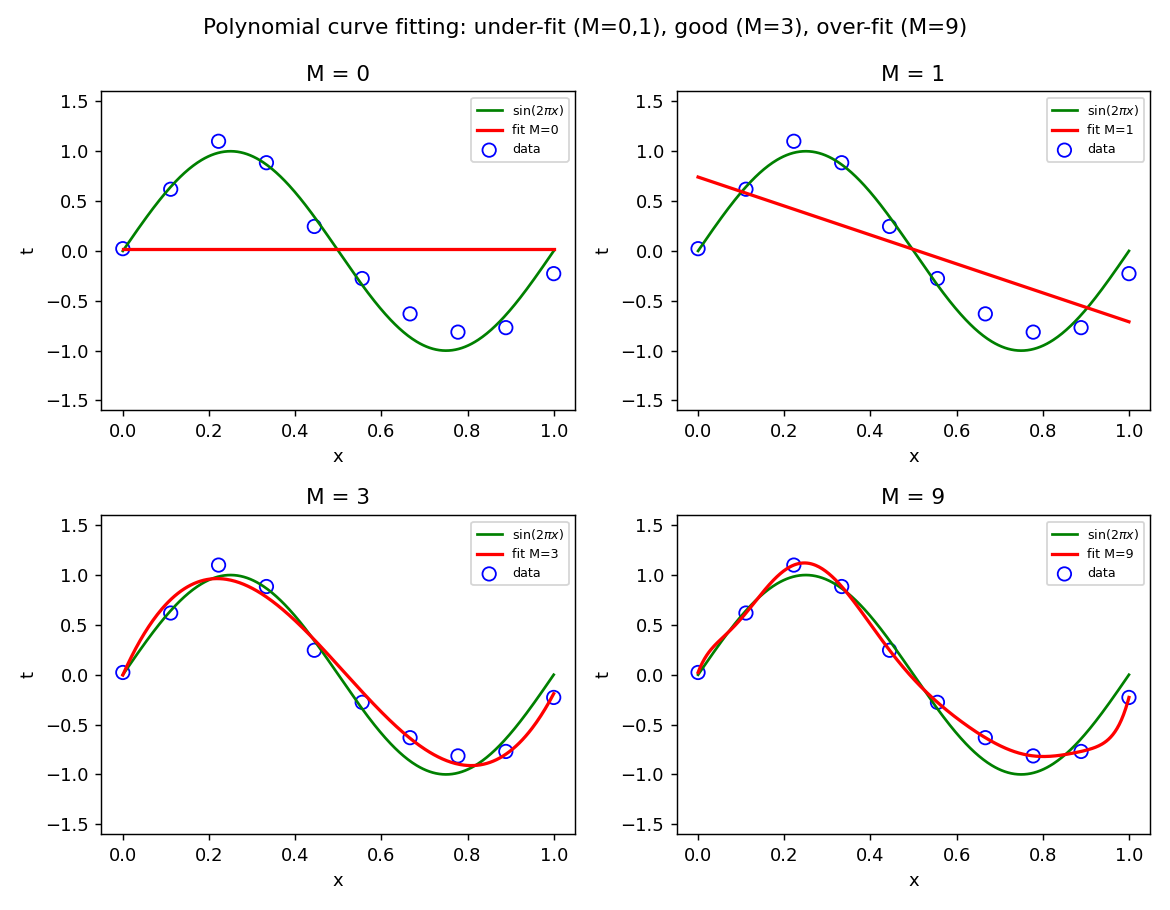

*Polynomial curve fitting: under-fit (M=0,1), good (M=3), over-fit (M=9). Run the next cell to regenerate.*


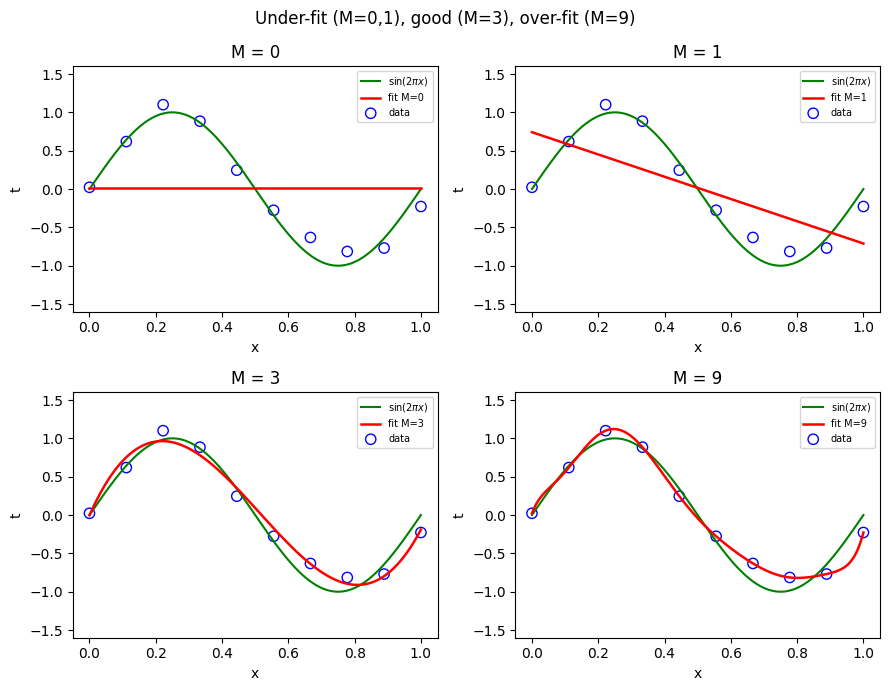

In [1]:
# Figure: polynomial curve fitting / over-fitting (Bishop Fig. 1.4-style)
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N = 10
x = np.linspace(0, 1, N)
t = np.sin(2 * np.pi * x) + rng.normal(0, 0.18, N)
xs = np.linspace(0, 1, 400)
truth = np.sin(2 * np.pi * xs)

def polyfit_predict(x, t, M, xs):
    X = np.vander(x, M + 1, increasing=True)
    w, *_ = np.linalg.lstsq(X, t, rcond=None)
    return np.vander(xs, M + 1, increasing=True) @ w

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, M in zip(axes.ravel(), [0, 1, 3, 9]):
    ax.plot(xs, truth, "g-", lw=1.5, label=r"$\sin(2\pi x)$")
    ax.plot(xs, polyfit_predict(x, t, M, xs), "r-", lw=1.8, label=f"fit M={M}")
    ax.scatter(x, t, facecolors="none", edgecolors="b", s=55, label="data")
    ax.set_title(f"M = {M}"); ax.set_ylim(-1.6, 1.6)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Under-fit (M=0,1), good (M=3), over-fit (M=9)")
fig.tight_layout(); plt.show()


# Bishop 1.2 — Probability Theory

*Grad-student summary + worked exercises. Source: Bishop, PRML §1.2.*

Probability is the framework for quantifying uncertainty — from noise in measurements and finite data. The whole chapter rests on **two rules**.

## The two rules of probability

Let $X$ take values $\{x_i\}$ and $Y$ take values $\{y_j\}$.

- **Sum rule** (marginalization):
$$p(X) = \sum_{Y} p(X, Y).$$
- **Product rule:**
$$p(X, Y) = p(Y \mid X)\, p(X).$$

From these, **Bayes' theorem**:
$$\boxed{\,p(Y \mid X) = \frac{p(X \mid Y)\, p(Y)}{p(X)}\,}, \qquad p(X) = \sum_Y p(X\mid Y)\,p(Y).$$
The denominator is the **normalization** that makes the posterior over $Y$ sum to 1.

**Vocabulary that recurs all book:**
- $p(Y)$ — **prior** (before seeing $X$).
- $p(Y\mid X)$ — **posterior** (after observing $X$).
- $p(X\mid Y)$ — **likelihood** (as a function of $Y$).
- posterior $\propto$ likelihood $\times$ prior.

**Independence:** $X,Y$ independent $\iff p(X,Y)=p(X)p(Y) \iff p(Y\mid X)=p(Y)$.

## Probability densities (continuous)

For continuous $x$, $p(x)$ is a **density**: $p(x\in(a,b)) = \int_a^b p(x)\,dx$, with $p(x)\ge0$ and $\int_{-\infty}^{\infty} p(x)\,dx = 1$. Cumulative distribution $P(z)=\int_{-\infty}^{z}p(x)\,dx$, $P'(x)=p(x)$.

⚠️ **Densities transform with a Jacobian.** Under $x=g(y)$,
$$p_y(y) = p_x(x)\left|\frac{dx}{dy}\right|.$$
Consequence: the location of the **maximum of a density is not invariant** under nonlinear reparameterization (unlike a true probability). Worth remembering when people "find the mode."

## Expectations and covariances

- **Expectation:** $\mathbb{E}[f] = \sum_x p(x) f(x)$ (discrete) or $\int p(x) f(x)\,dx$ (continuous).
- **Monte-Carlo estimate** from samples: $\mathbb{E}[f] \approx \frac{1}{N}\sum_{n=1}^N f(x_n)$.
- **Variance:** $\operatorname{var}[f] = \mathbb{E}\big[(f - \mathbb{E}[f])^2\big] = \mathbb{E}[f^2] - \mathbb{E}[f]^2.$
- **Covariance:** $\operatorname{cov}[x,y] = \mathbb{E}_{x,y}\big[(x-\mathbb{E}[x])(y-\mathbb{E}[y])\big] = \mathbb{E}[xy]-\mathbb{E}[x]\mathbb{E}[y].$ For vectors, $\operatorname{cov}[\mathbf{x}] = \mathbb{E}[(\mathbf{x}-\bar{\mathbf{x}})(\mathbf{x}-\bar{\mathbf{x}})^\mathsf{T}]$, a matrix.

## Bayesian vs. frequentist

- **Frequentist:** probability = long-run frequency; $\mathbf{w}$ is a fixed unknown; estimate it (e.g. **maximum likelihood**), quantify uncertainty via error bars / the **bootstrap** over imagined repeated datasets.
- **Bayesian:** probability = degree of belief; treat $\mathbf{w}$ as a random variable with a prior $p(\mathbf{w})$; condition on the *single* observed dataset $\mathcal{D}$:
$$p(\mathbf{w}\mid\mathcal{D}) = \frac{p(\mathcal{D}\mid\mathbf{w})\,p(\mathbf{w})}{p(\mathcal{D})}.$$
Here $p(\mathcal{D}\mid\mathbf{w})$ is the **likelihood** — *not* a probability over $\mathbf{w}$, but the data probability as a function of $\mathbf{w}$.

**Maximum likelihood (ML):** choose $\mathbf{w}$ maximizing $p(\mathcal{D}\mid\mathbf{w})$, equivalently minimizing $-\ln p(\mathcal{D}\mid\mathbf{w})$ (the "error function"). Bishop's caution: ML can **over-fit**; the Bayesian prior acts like a built-in regularizer. Critique of Bayes: results depend on the prior choice.

## The Gaussian

Univariate:
$$\mathcal{N}(x\mid\mu,\sigma^2) = \frac{1}{(2\pi\sigma^2)^{1/2}}\exp\!\Big\{-\frac{1}{2\sigma^2}(x-\mu)^2\Big\},$$
mean $\mathbb{E}[x]=\mu$, variance $\operatorname{var}[x]=\sigma^2$, precision $\beta=1/\sigma^2$. Multivariate over $D$ dims:
$$\mathcal{N}(\mathbf{x}\mid\boldsymbol\mu,\boldsymbol\Sigma)=\frac{1}{(2\pi)^{D/2}|\boldsymbol\Sigma|^{1/2}}\exp\!\Big\{-\tfrac12(\mathbf{x}-\boldsymbol\mu)^\mathsf{T}\boldsymbol\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu)\Big\}.$$

**ML for a Gaussian** from i.i.d. data $\{x_n\}$: maximize $\ln p(\mathbf{x}\mid\mu,\sigma^2)$ →
$$\mu_\text{ML} = \frac1N\sum_n x_n \ \text{(sample mean)},\qquad \sigma^2_\text{ML} = \frac1N\sum_n (x_n-\mu_\text{ML})^2.$$
**Bias:** $\mathbb{E}[\sigma^2_\text{ML}] = \frac{N-1}{N}\sigma^2$ — ML *under-estimates* the variance. The unbiased fix divides by $N-1$. This bias is a small concrete instance of over-fitting and vanishes as $N\to\infty$.

## Curve fitting re-visited (probabilistic view)

Model the target as Gaussian around the polynomial:
$$p(t\mid x,\mathbf{w},\beta) = \mathcal{N}\big(t \mid y(x,\mathbf{w}),\ \beta^{-1}\big).$$
Maximizing the log-likelihood over $\mathbf{w}$ is **equivalent to minimizing sum-of-squares error** — least squares falls out of a Gaussian noise assumption. Maximizing over $\beta$ gives the noise precision.

Add a prior $p(\mathbf{w}\mid\alpha)=\mathcal{N}(\mathbf{w}\mid\mathbf{0},\alpha^{-1}\mathbf{I})$ and maximize the posterior (**MAP**): this is **equivalent to regularized least squares** with $\lambda=\alpha/\beta$. So regularization = a Gaussian prior on the weights. (Connects straight back to §1.1.)

**Fully Bayesian** curve fitting integrates over $\mathbf{w}$ rather than picking one value:
$$p(t\mid x,\mathbf{x},\mathbf{t}) = \int p(t\mid x,\mathbf{w})\,p(\mathbf{w}\mid\mathbf{x},\mathbf{t})\,d\mathbf{w},$$
yielding a **predictive distribution** — a mean prediction *with* input-dependent error bars, not a point estimate.

---

## Worked exercise (self-set, Bayes' theorem)

**Q (Bishop's fruit-boxes example):** Red box chosen with $p(B{=}r)=0.4$, blue with $p(B{=}b)=0.6$. Red box: 2 apples, 6 oranges. Blue box: 3 apples, 1 orange. We draw a fruit and it's an **orange**. What's $p(B{=}r\mid \text{orange})$?

**A:** Likelihoods: $p(o\mid r)=6/8=0.75$, $p(o\mid b)=1/4=0.25$.
Evidence (sum rule):
$$p(o)=p(o\mid r)p(r)+p(o\mid b)p(b)=0.75(0.4)+0.25(0.6)=0.30+0.15=0.45.$$
Bayes:
$$p(r\mid o)=\frac{p(o\mid r)p(r)}{p(o)}=\frac{0.30}{0.45}=\frac{2}{3}\approx0.667.$$
The prior on red was $0.4$; observing an orange **raises** it to $0.667$ because oranges are more common in the red box. That update *is* learning. $\blacksquare$

See `img_bayes_fruit.png` for the prior→posterior shift.


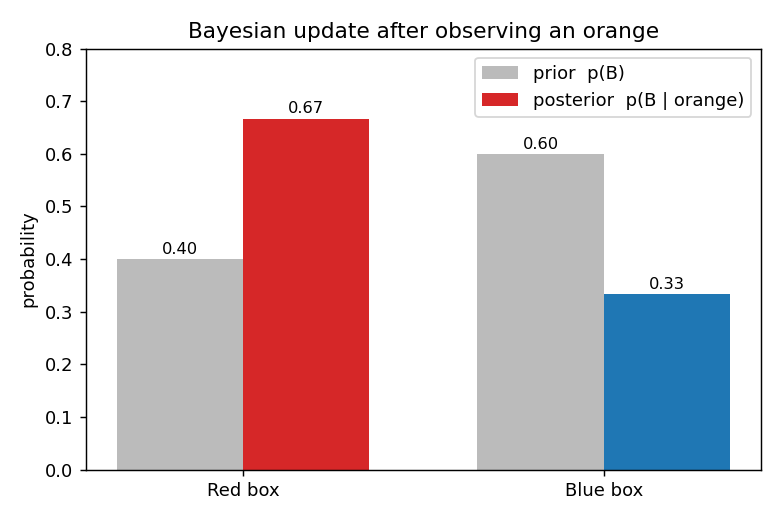

*Prior to posterior for the fruit-box example. Run the next cell to regenerate.*


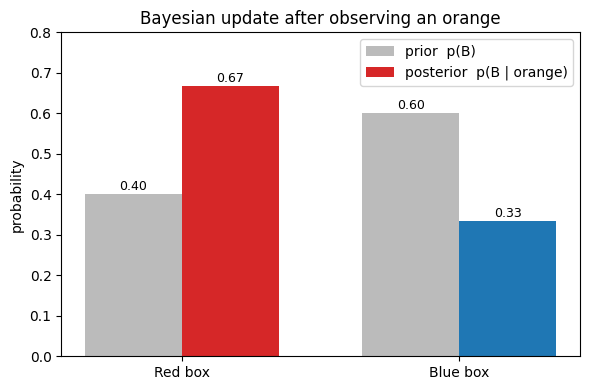

In [2]:
# Figure: Bayesian update for the fruit-box example
import numpy as np
import matplotlib.pyplot as plt

labels = ["Red box", "Blue box"]
prior = [0.4, 0.6]
post  = [2/3, 1/3]
xpos = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(xpos - w/2, prior, w, label="prior  p(B)", color="#bbbbbb")
ax.bar(xpos + w/2, post,  w, label="posterior  p(B | orange)", color=["#d62728", "#1f77b4"])
for i, (a, b) in enumerate(zip(prior, post)):
    ax.text(i - w/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
ax.set_xticks(xpos); ax.set_xticklabels(labels)
ax.set_ylim(0, 0.8); ax.set_ylabel("probability")
ax.set_title("Bayesian update after observing an orange"); ax.legend()
fig.tight_layout(); plt.show()


# Bishop 1.3 — Model Selection

*Grad-student summary. Source: Bishop, PRML §1.3.*

## The problem

In §1.1 the polynomial order $M$ controlled complexity; with regularization the knob became $\lambda$. Both are **hyperparameters** (model-selection parameters) — not fitted by minimizing training error, because more complexity always lowers training error. We need to estimate **generalization** performance to choose them.

## Validation set

- Split data: **train** (fit $\mathbf{w}$) + **validation / hold-out** (compare models / pick hyperparameters).
- If the validation set is also small and reused heavily, you can over-fit *it*; keep a final **test set**, touched once, for an honest performance number.
- Drawback: data used for validation is "wasted" for training — costly when data is scarce.

## Cross-validation

Use (almost) all data for both training and validation by rotating the hold-out fold.

**$S$-fold cross-validation:**
1. Partition data into $S$ equal groups.
2. For each fold $s=1\ldots S$: train on the other $S-1$ groups, validate on group $s$.
3. Average the $S$ validation scores.

- Uses a fraction $(S-1)/S$ for training each run.
- **Leave-one-out (LOO):** the extreme $S=N$ — maximal training data, but $N$ separate fits.

**Costs / limits:**
- Training runs multiply by $S$ — expensive for already-costly models.
- With several hyperparameters, grid-searching combinations is exponential in their count. This motivates better complexity criteria.

## Information criteria (penalize complexity analytically)

Instead of held-out data, add a penalty for the number of parameters $M$ to the maximized log-likelihood:

- **Akaike Information Criterion (AIC):** choose the model maximizing
$$\ln p(\mathcal{D}\mid\mathbf{w}_\text{ML}) - M.$$
- **Bayesian Information Criterion (BIC):** a variant (derived §4.4.1) with a heavier, $N$-dependent penalty $\sim \tfrac12 M\ln N$.

Bishop's verdict: these criteria are **crude** — they rely only on parameter *count*, ignore parameter uncertainty, and tend to favor over-simple models. The **fully Bayesian** approach (§3.4, model evidence / marginal likelihood) handles complexity more gracefully and, crucially, can be done using **training data alone** without a separate validation set.

---

## Quick intuition recap
- Can't pick complexity by training error → it monotonically improves with complexity.
- Hold-out / cross-validation = empirical generalization estimate (robust, but costs compute & data).
- Information criteria = cheap analytic proxy (but crude).
- Bayesian evidence = the principled route, deferred to later chapters.

See `img_cross_validation.png` for the $S$-fold rotation diagram.


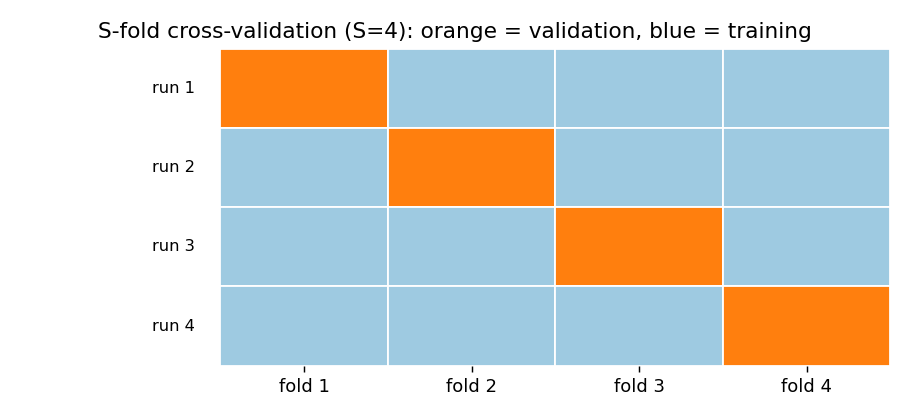

*S-fold cross-validation rotation (S=4). Run the next cell to regenerate.*


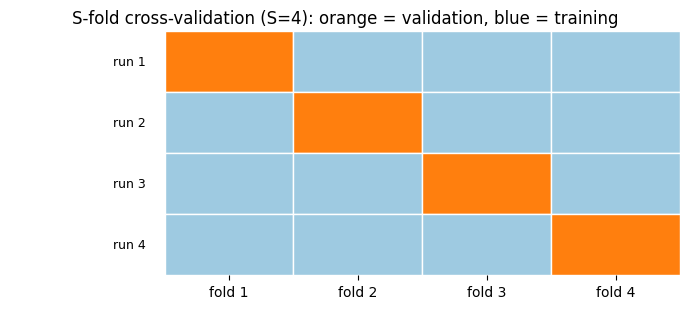

In [3]:
# Figure: S-fold cross-validation diagram
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

S = 4
fig, ax = plt.subplots(figsize=(7, 3.2))
for run in range(S):
    for fold in range(S):
        color = "#ff7f0e" if fold == run else "#9ecae1"
        ax.add_patch(Rectangle((fold, S - 1 - run), 1, 1, facecolor=color, edgecolor="white"))
    ax.text(-0.15, S - 0.5 - run, f"run {run+1}", ha="right", va="center", fontsize=9)
ax.set_xlim(-1.2, S); ax.set_ylim(0, S)
ax.set_xticks(np.arange(S) + 0.5); ax.set_xticklabels([f"fold {i+1}" for i in range(S)])
ax.set_yticks([])
ax.set_title("S-fold cross-validation (S=4): orange = validation, blue = training")
for sp in ax.spines.values(): sp.set_visible(False)
fig.tight_layout(); plt.show()


# Bishop 1.1–1.3 — Q&A Log

*Running log of questions asked during the reading session and their answers.*

---

## Q1. What is a training set and a target vector? (§1.1)

**Training set** — the collection of example data the model learns from. In the curve-fitting
example it is $N$ observations of the input $x$:
$$\mathbf{x} = (x_1, \ldots, x_N)^\mathsf{T}.$$
Called "training" because the parameters $\mathbf{w}$ are *fit* on it. Each $x_n$ may itself be a
feature vector; in this example it's a single scalar.

**Target vector** — the stacked column of the desired outputs, one per training input:
$$\mathbf{t} = (t_1, \ldots, t_N)^\mathsf{T}.$$
$t_n$ is the answer paired with input $x_n$. In Bishop's example $t_n = \sin(2\pi x_n) + \epsilon_n$,
but the learner sees only the noisy $t_n$, not the generating sine.

**Relationship:** training adjusts $\mathbf{w}$ so predictions $y(x_n,\mathbf{w})$ match the targets
$t_n$; the goal is then to predict $\hat t$ for an unseen $\hat x$ (**generalization**).

*Terminology:* "target **vector**" = the $N$ scalar targets gathered into one $N$-dim column — distinct
from the (separate) idea of each input being multi-dimensional.

---

## Q2. What is generalization? (§1.1)

**Generalization** — a trained model's ability to predict accurately on **new, unseen inputs** not in
the training set. It is the real goal of ML; fitting the training data is only the means.

**Why central:** with $N=10$ noisy points we want $y(\hat x,\mathbf{w})$ correct for *any*
$\hat x\in[0,1]$, including the infinitely many never observed. Memorizing the training targets is
useless without interpolation to new $\hat x$.

**Why hard:** training data is finite and noisy. Enough flexibility (e.g. $M=9$ through all 10 points)
drives training error to zero but fits the **noise** → wild oscillation → poor predictions. That is
**over-fitting**: low training error, poor generalization.

**How measured:** not by training error (monotonically improves with complexity) but on held-out data —
a **test set** or **cross-validation** (§1.3). The train-vs-test error gap *is* the generalization gap.

**What helps:** more data, limiting complexity ($M$), or **regularization** (penalizing large
$\mathbf{w}$). Every tool in §1.1 targets generalization, not training fit.

---

## Q3. What is feature extraction? (chapter intro / §1.1)

**Feature extraction** — preprocessing that transforms raw inputs into a new representation (a set of
**features**) that makes learning easier. Part of the **preprocessing** stage.

**Why:**
- **Reduce variability / dimensionality** — raw inputs (e.g. all image pixels) are high-dimensional
  with much irrelevant variation; informative features expose patterns and speed computation.
- **Speed** — fewer features → faster training *and* prediction (matters for real-time use).
- **Inject prior knowledge** — design features to surface what matters and suppress what doesn't.

**Example (digit recognition):** instead of raw pixels, extract features like stroke count, aspect
ratio, or ink-density regions — quantities that differ between digit classes but stay roughly constant
across instances of the same digit.

**Invariance:** prefer features invariant to transformations that shouldn't change the answer
(translation, scaling) — a digit's identity is unchanged by shifting or resizing it.

**Caveat — information loss:** preprocessing can *discard* information; if a useful distinction is
thrown away, no later algorithm recovers it. Feature choice can cap achievable accuracy — a design
trade-off, not a free win.

*(added context: in §1.1 the "features" are the powers $1,x,x^2,\ldots,x^M$ — a fixed transform of
scalar $x$; generalized to basis functions $\phi_j(x)$ in Ch. 3.)*

---

## Q4. Clustering, density estimation, visualization? (chapter intro)

All three are **unsupervised learning** tasks — training data has inputs $\mathbf{x}$ but **no target
labels** $t$ (contrast supervised = classification/regression).

**Clustering** — discover groups of similar examples; partition inputs so within-cluster points are
more alike than across-cluster. Found purely from structure in $\mathbf{x}$. *E.g.* grouping customers
by behavior. (Bishop's later example: $K$-means.)

**Density estimation** — model the distribution $p(\mathbf{x})$ over input space: where data is dense
vs. sparse. *Use:* anomaly detection (low-density = outlier), generative modeling. Ties to §1.2.

**Visualization** — project high-dimensional data to 2-D/3-D for human inspection, preserving
meaningful (near/far) relationships. *E.g.* a 100-feature set → 2-D scatter. (PCA, Ch. 12 — added context.)

**Unifying idea:** extract structure from **unlabeled** data — *where are the groups* (clustering),
*where is the data* (density estimation), *what does it look like* (visualization).

**Full taxonomy:**

| Paradigm | Has targets? | Tasks |
|---|---|---|
| Supervised | yes | classification (discrete $t$), regression (continuous $t$) |
| Unsupervised | no | clustering, density estimation, visualization |
| Reinforcement | reward signal | learn actions to maximize reward |

---

## Q5. What is reinforcement learning? (chapter intro)

**Reinforcement learning (RL)** — finding suitable **actions** in a given situation to **maximize a
reward**. The learner is never told correct outputs; it must **discover** them by trial and error
through interaction.

**vs. supervised:** supervised gives the right answer per input; RL gives only a **reward** signal
(evaluative feedback), not the correct action (instructive feedback). vs. unsupervised: RL *has*
feedback (reward); unsupervised has none.

**Key features:**
- **Learning by interaction / trial and error** — try actions, observe reward, adjust; states and
  actions unfold over time.
- **Credit assignment** — rewards are often **delayed** and apply to a whole *sequence* of actions;
  must infer which earlier actions earned the outcome. (*Bishop's example:* a neural net learning
  backgammon by self-play — reward only at game end, yet every move must be evaluated.)
- **Exploration vs. exploitation** — *exploitation* uses known-good actions; *exploration* tries new
  ones that might be better. Too much of either is suboptimal; balancing them is fundamental.

Bishop notes RL is a large field the book does not cover in depth.

---

## Q6. What is regularization? (§1.1)

**Regularization** — controlling over-fitting by **adding a penalty to the error function** that
discourages large coefficients $\mathbf{w}$. Keep the flexible model, but penalize extreme solutions
(instead of shrinking the order $M$).

**Mechanism:** add a quadratic penalty to sum-of-squares error,
$$\widetilde{E}(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^{N}\big\{y(x_n,\mathbf{w}) - t_n\big\}^2
  + \frac{\lambda}{2}\lVert \mathbf{w}\rVert^2,\qquad
  \lVert\mathbf{w}\rVert^2 = \mathbf{w}^\mathsf{T}\mathbf{w} = \sum_{j} w_j^2.$$

**Why it works:** over-fitting shows up as **huge alternating-sign coefficients** that thread through
noisy points. The penalty makes large $\mathbf{w}$ expensive, trading a little training fit for smaller,
smoother coefficients → smoother curve → better generalization.

**The knob $\lambda$ (effective complexity):**
- $\lambda\to0$: penalty vanishes → over-fits.
- $\lambda$ moderate: smooth, good fit.
- $\lambda$ too large: coefficients crushed → under-fits.

It replaces the discrete knob $M$ with a continuous one.

**Names:** $L_2$ penalty = **ridge regression** (statistics) = **weight decay** (neural nets).

**Connection (§1.2):** minimizing $\widetilde{E}$ = **MAP** estimation with a Gaussian prior
$p(\mathbf{w})=\mathcal{N}(\mathbf{w}\mid\mathbf{0},\alpha^{-1}\mathbf{I})$, where $\lambda=\alpha/\beta$.
The penalty *is* a prior that weights should be small.

---

## Q7. The ABCs of what the Bayesian interpretation means (§1.2.3)

**Two interpretations of probability:**
- **Frequentist:** probability = **long-run frequency** of a repeatable event ($p=0.5$ heads means
  half of infinitely many flips). Only meaningful for repeatable things.
- **Bayesian:** probability = **degree of belief / quantified uncertainty** — valid even for one-off,
  non-repeatable events ("70% chance of rain tomorrow"). This is the core idea.

**The ABCs of the procedure:**
- **A — Assign a prior** $p(\mathbf{w})$: belief about parameters *before* data.
- **B — Bring in data via the likelihood** $p(\mathcal{D}\mid\mathbf{w})$: how probable the observed
  data is for each $\mathbf{w}$ (a function of $\mathbf{w}$, not a distribution over it).
- **C — Combine with Bayes' theorem** to get the **posterior**:
$$p(\mathbf{w}\mid\mathcal{D}) = \frac{p(\mathcal{D}\mid\mathbf{w})\,p(\mathbf{w})}{p(\mathcal{D})},
  \qquad \text{posterior} \propto \text{likelihood}\times\text{prior}.$$

**The deep shift:**

| | Frequentist | Bayesian |
|---|---|---|
| What is $\mathbf{w}$? | fixed unknown constant | random variable with a distribution |
| Data $\mathcal{D}$ | one of many possible datasets | the single observed (fixed) dataset |
| Uncertainty in… | the estimator (error bars over repeats) | the parameters (the posterior) |
| Output | point estimate ($\mathbf{w}_\text{ML}$) | full distribution $p(\mathbf{w}\mid\mathcal{D})$ |

**Payoff:** a distribution over $\mathbf{w}$ expresses *how confident* you are → error bars, predictive
distributions, built-in over-fitting defense (prior = regularization, cf. Q6).

**Honest catch:** results depend on the **choice of prior** (criticized as subjective). Bayesians reply
that all assumptions should be explicit; as data grows the likelihood dominates and the prior's
influence fades.

---

## Q8. Why do we care about maximizing the log-likelihood? (§1.2)

**Why maximize the likelihood:** $p(\mathcal{D}\mid\mathbf{w})$ = how probable the *observed* data is
under parameters $\mathbf{w}$. **Maximum likelihood** picks the $\mathbf{w}$ making the observed data
**most probable** — the model that best explains what actually happened.

**Why the *log* (same optimum, since $\ln$ is monotonic):**
$$\arg\max_{\mathbf{w}} p(\mathcal{D}\mid\mathbf{w}) = \arg\max_{\mathbf{w}} \ln p(\mathcal{D}\mid\mathbf{w}).$$

1. **Products → sums (main reason).** i.i.d. data ⇒ likelihood is a product
   $p(\mathcal{D}\mid\mathbf{w})=\prod_{n} p(t_n\mid\mathbf{w})$; the log turns it into a sum
   $\sum_n \ln p(t_n\mid\mathbf{w})$, which is far easier to **differentiate** (and we differentiate to
   find the max).
2. **Numerical stability.** Each factor $\in(0,1)$; multiplying many **underflows** to 0 in
   floating-point. Summing logs stays in safe range — real code works in log-space.
3. **Connects to error functions.** Maximizing $\ln p$ = minimizing the **negative log-likelihood**,
   which *is* the error function. Under **Gaussian noise**, $-\ln p$ reduces to exactly the
   **sum-of-squares error** — so **least squares = ML under Gaussian noise** (the $\exp\{-\tfrac12(\cdot)^2\}$
   log-drops to the squared term).

**Takeaway:** same optimum as the likelihood, but converts an underflow-prone product into a stable,
differentiable sum that equals the familiar error function.

---

## Q9. What is over-fitting? (§1.1)

**Over-fitting** — a model fits the **training data too well, including its noise**, and so
**generalizes poorly** to new data. Low training error, high test error. The central failure mode of §1.1.

**Picture (fitting $\sin(2\pi x)$ from 10 noisy points):**
- **$M=9$**: 10 coefficients pass through all 10 points exactly ($E=0$) but **oscillate wildly** between
  them → useless predictions. *That's over-fitting.* (See `img_polyfit_overfitting.png`.)
- **$M=3$**: misses individual points but tracks the true curve → generalizes well.

**Why:** model too flexible relative to data → memorizes the *specific noise* instead of the underlying
pattern; noise won't repeat, so the fit doesn't transfer.

**Detect:**
- **Train/test error gap** — training error keeps falling as $M$ grows; test $E_\text{RMS}$ dips then
  shoots up. The gap *is* over-fitting (invisible from training error alone).
- **Coefficient blow-up** — fingerprint: huge alternating-sign coefficients ($\sim\pm10^5$ at $M=9$).

**Combat (all §1.1):** more data · reduce complexity (smaller $M$) · **regularization** (penalize large
$\mathbf{w}$, Q6).

**Deeper tension:** a higher-order polynomial contains all lower ones, so it's nominally more capable yet
generalizes worse — the fit-vs-generalization trade-off (bias–variance, Ch. 3 — added context) recurs
all book. Opposite failure = **under-fitting** ($M=0,1$): too rigid to capture the pattern.

---

## Q10. What is cross-validation, with an example? (§1.3)

**Cross-validation** — estimate generalization by rotating which portion of data is held out, so
**every point is used for both training and validation** (never simultaneously). Fixes the waste and
noisiness of a single fixed validation set.

**$S$-fold recipe:** (1) split data into $S$ equal folds; (2) for each fold $s$, train on the other
$S-1$ folds and score on fold $s$; (3) average the $S$ scores. Repeat per candidate model; pick the
best average. **LOO** = extreme $S=N$ (one point per fold). See `img_cross_validation.png`.

**Worked example — 20 points, choose $M$ via 5-fold (4 pts/fold):**

| Run | Train (16 pts) | Validate (4 pts) | Error |
|---|---|---|---|
| 1 | folds 2–5 | fold 1 | $e_1$ |
| 2 | folds 1,3,4,5 | fold 2 | $e_2$ |
| 3 | folds 1,2,4,5 | fold 3 | $e_3$ |
| 4 | folds 1,2,3,5 | fold 4 | $e_4$ |
| 5 | folds 1–4 | fold 5 | $e_5$ |

$\text{CV}(M)=\tfrac15\sum e_i$. Testing $M\in\{1,3,9\}$ might give CV errors $0.42$ (under-fit) /
$\mathbf{0.11}$ / $0.95$ (over-fit) → pick **$M=3$**, using all 20 points to decide.

**Why:** data-efficient (nothing permanently set aside — matters when data is scarce) and more reliable
(averages over $S$ splits, less luck-of-the-draw).

**Cost:** $S\times$ the training (LOO worst); with several hyperparameters the grid of runs grows
**exponentially** — motivates AIC/BIC and the Bayesian approach.
